- NAME: ARPITHA
- TEAM ID: PTID-CDS-DEC-25-3550
- PROJECT ID: PRCL-0027 – Inventory Forecasting for JIT Optimization
- BATCH ID: 18-AGU-25-CDS-WDM09-BAN-AEN

 PRCL-0027 – Inventory Forecasting for JIT Optimization

#  Executive Summary

This project focuses on forecasting spare parts demand to support 
Just-In-Time (JIT) inventory optimization.

Business Problem:
Uncertain spare parts demand leads to overstocking or stockouts,
increasing operational cost.

Solution Approach:
- Performed Exploratory Data Analysis (EDA)
- Engineered time-based and lag features
- Implemented Decision Tree and Random Forest models
- Compared model performance using MAE and RMSE
- Forecasted next 6 months demand
- Calculated Safety Stock and Reorder Point

Final Outcome:
Random Forest provided better prediction accuracy.
Using forecasting + inventory optimization metrics,
inventory planning can be improved significantly.

#  Introduction

Inventory management plays a critical role in service-based organizations. 
Maintaining optimal spare parts inventory ensures smooth operations, cost efficiency, and high customer satisfaction.

NewX Services operates multiple service centres and faces challenges in maintaining spare parts inventory efficiently. 
This project focuses on leveraging data analytics and machine learning to forecast spare parts demand and support Just-In-Time (JIT) inventory management.

#  Project Objective

The objective of this project is to:

- Analyze historical spare parts transaction data
- Identify demand trends and patterns
- Build machine learning models to forecast future demand
- Calculate safety stock and reorder points
- Support Just-In-Time (JIT) inventory strategy

#  Problem Statement

Service centres at NewX Services:

- Maintain high inventory holding costs
- Still experience spare parts shortages
- Lack a data-driven demand forecasting system

This results in:
- Increased operational cost
- Stockouts
- Delayed service delivery
- Reduced customer satisfaction

A predictive forecasting model is required to optimize inventory levels and achieve JIT standards.

#  Data Understanding

The dataset contains service transaction data with the following key features:

- invoice_date → Date of service invoice
- job_card_date → Service job reference date
- business_partner_name → Customer details
- vehicle_no → Vehicle identification
- vehicle_model → Vehicle model information
- current_km_reading → Usage level of vehicle
- invoice_line_text → Spare parts/service description

For forecasting purposes:
- invoice_date is used for time-based analysis
- invoice_line_text represents spare part transactions

Monthly aggregation is performed to create a time-series demand dataset.

#  Project Summary

This project successfully:

- Cleaned and structured service transaction data
- Aggregated monthly spare parts demand
- Built Decision Tree and Random Forest models
- Selected best-performing model
- Forecasted future demand
- Calculated safety stock and reorder point

The solution enables NewX Services to reduce inventory costs,
avoid stockouts, and achieve Just-In-Time inventory management.

#  Key Insights from EDA

- Monthly demand shows fluctuating patterns over time.
- Some months experience higher demand peaks.
- Rolling average indicates an overall stable to slightly increasing trend.
- Demand variability suggests the need for safety stock.
- Lag features significantly improve model prediction performance.

Business Understanding

#  PRCL-0027 – Inventory Forecasting for JIT Optimization

##  Client: NewX Services  
##  Goal:
To build a predictive model to forecast spare parts demand so service centres can achieve Just-In-Time (JIT) inventory standards.


##  Business Problem

Service centres:
- Maintain high inventory cost
- Still face spare shortages
- Cannot predict demand accurately


##  Solution Strategy

- Data Cleaning
- Monthly Demand Aggregation
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Machine Learning Models
- Forecasting
- Inventory Optimization (Safety Stock & Reorder Point)

Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

Load Dataset

In [2]:
df = pd.read_csv(r"C:\Users\ARPITHA\Documents\Business Case_PM-PR-0027.csv")
df.head()

,invoice_date,job_card_date,business_partner_name,vehicle_no,vehicle_model,current_km_reading,invoice_line_text
0,30-05-17,30-05-17,shivXXXXXXXXXX,KA03MFXXXX,BAJAJ AVENGER STREET 220,50000,ENGINE OIL
1,02-06-17,31-05-17,KIRAXXXXXXXXXX,KA53ESXXXX,BAJAJ PULSAR NS 200,758,ENGINE OIL
2,02-06-17,31-05-17,KIRAXXXXXXXXXX,KA53ESXXXX,BAJAJ PULSAR NS 200,758,POLISH
3,02-06-17,31-05-17,KIRAXXXXXXXXXX,KA53ESXXXX,BAJAJ PULSAR NS 200,758,CONSUMABLES
4,02-06-17,31-05-17,KIRAXXXXXXXXXX,KA53ESXXXX,BAJAJ PULSAR NS 200,758,COOLANT OIL


#  Data Cleaning & Preprocessing

We perform:

- Convert invoice_date to datetime format
- Remove missing invoice dates
- Remove missing spare transaction text

In [3]:
df['invoice_date'] = pd.to_datetime(df['invoice_date'], errors='coerce')

df = df.dropna(subset=['invoice_date'])
df = df.dropna(subset=['invoice_line_text'])

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28448 entries, 0 to 28481
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   invoice_date           28448 non-null  datetime64[ns]
 1   job_card_date          28448 non-null  object        
 2   business_partner_name  28448 non-null  object        
 3   vehicle_no             28448 non-null  object        
 4   vehicle_model          28448 non-null  object        
 5   current_km_reading     28448 non-null  int64         
 6   invoice_line_text      28448 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(5)
memory usage: 1.7+ MB


#  Monthly Demand Aggregation

Each invoice line represents a spare part transaction.
We aggregate demand on a monthly basis.

In [4]:
df['year_month'] = df['invoice_date'].dt.to_period('M')

monthly_demand = df.groupby('year_month').size().reset_index(name='demand')

monthly_demand['year_month'] = monthly_demand['year_month'].astype(str)

monthly_demand.head()

,year_month,demand
0,2017-01,376
1,2017-02,254
2,2017-03,239
3,2017-04,336
4,2017-05,248


Exploratory Data Analysis (EDA)

Trend Graph

#  Monthly Demand Trend

This graph shows demand variation over time.

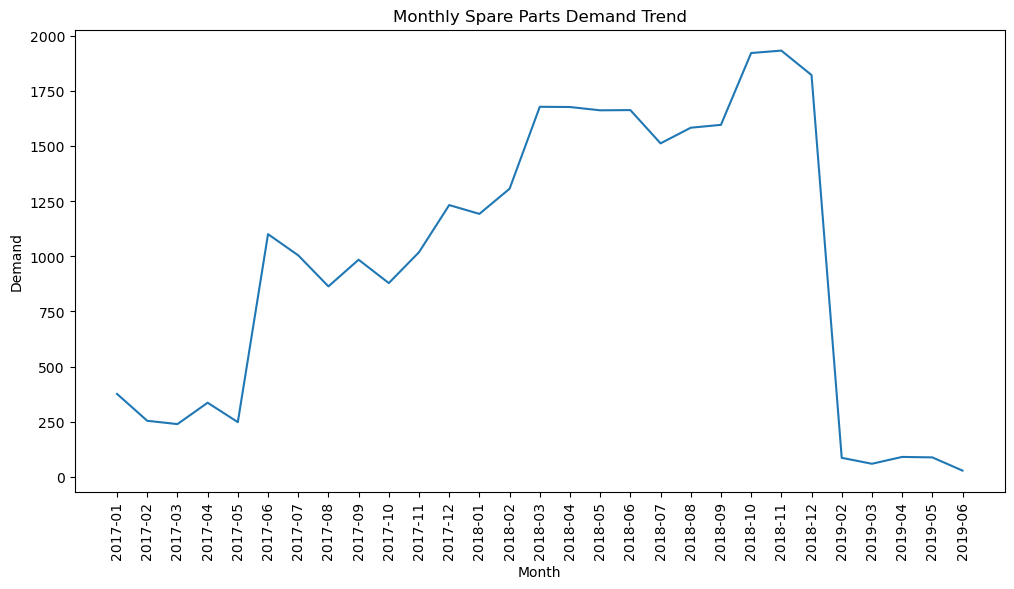

In [5]:
plt.figure(figsize=(12,6))
plt.plot(monthly_demand['year_month'], monthly_demand['demand'])
plt.xticks(rotation=90)
plt.title("Monthly Spare Parts Demand Trend")
plt.xlabel("Month")
plt.ylabel("Demand")
plt.show()

##  Graph Interpretation: Monthly Demand Trend

This graph shows the variation of spare parts demand over time.

Observations:
- Demand fluctuates across different months.
- Certain months show peak demand levels.
- There is no completely stable pattern, indicating variability.
- Slight upward/downward movement suggests trend changes over time.

Business Meaning:
Demand for spare parts is not constant. 
Forecasting is necessary to manage inventory efficiently and prevent stockouts or overstocking.

#  Rolling Average Trend

Rolling average smooths fluctuations and highlights overall trend.

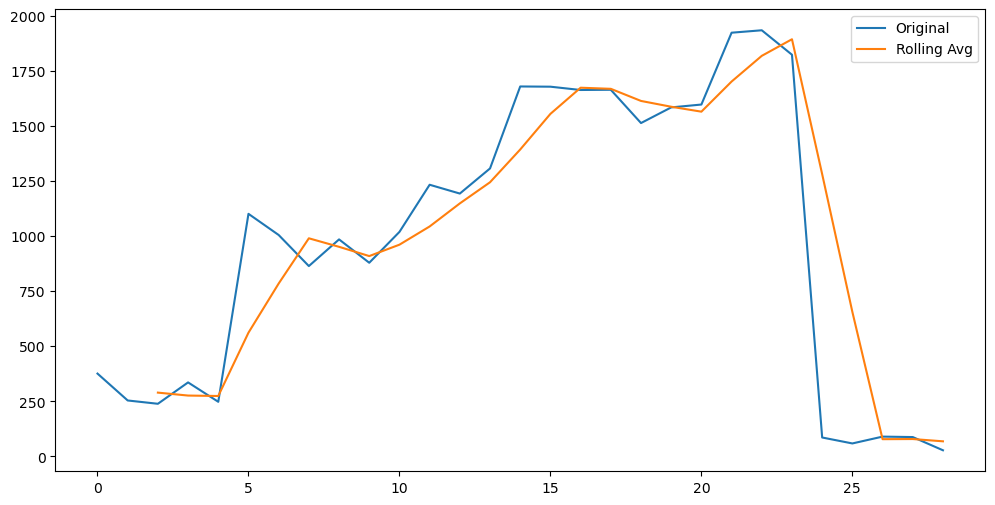

In [6]:
monthly_demand['rolling_mean'] = monthly_demand['demand'].rolling(window=3).mean()

plt.figure(figsize=(12,6))
plt.plot(monthly_demand['demand'], label='Original')
plt.plot(monthly_demand['rolling_mean'], label='Rolling Avg')
plt.legend()
plt.show()

##  Graph Interpretation: Rolling Average Trend

The rolling average smooths short-term fluctuations
and highlights long-term trends in demand.

Observations:
- The smoothed line reduces sudden spikes.
- It shows overall direction of demand more clearly.
- Trend appears relatively stable with periodic changes.

Business Meaning:
Rolling averages help inventory planners understand long-term demand behavior
instead of reacting to short-term fluctuations.

Histogram

#  Demand Distribution

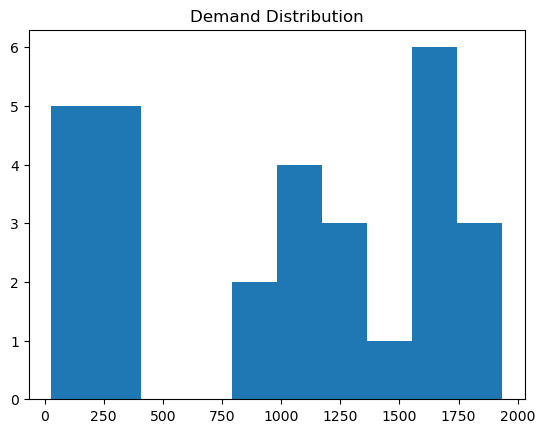

In [7]:
plt.hist(monthly_demand['demand'], bins=10)
plt.title("Demand Distribution")
plt.show()

## Graph Interpretation: Demand Distribution

The histogram shows how frequently different demand levels occur.

Observations:
- Most months fall within a certain demand range.
- Few months show extreme high or low demand.
- Distribution indicates moderate variability.

Business Meaning:
Understanding demand distribution helps calculate safety stock
and manage uncertainty in spare parts consumption.

Boxplot

# Outlier Detection

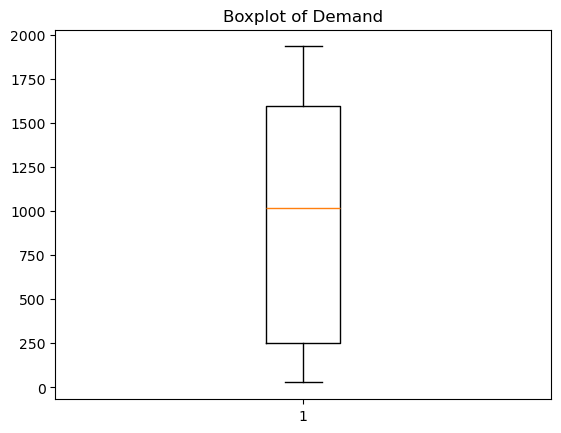

In [8]:
plt.boxplot(monthly_demand['demand'])
plt.title("Boxplot of Demand")
plt.show()

##  Graph Interpretation: Outlier Detection

The boxplot helps identify extreme demand months.

Observations:
- The box represents the middle 50% of demand values.
- Whiskers show normal variation range.
- Any points outside whiskers represent outliers.

Business Meaning:
Outlier months require special attention.
Inventory planning must consider sudden demand spikes.

#  Feature Engineering

We create:

- Month Index
- Lag Features (previous demand values)

In [9]:
monthly_demand['month_index'] = range(1, len(monthly_demand)+1)

monthly_demand['lag_1'] = monthly_demand['demand'].shift(1)
monthly_demand['lag_2'] = monthly_demand['demand'].shift(2)
monthly_demand['lag_3'] = monthly_demand['demand'].shift(3)

monthly_demand = monthly_demand.dropna()

X = monthly_demand[['month_index','lag_1','lag_2','lag_3']]
y = monthly_demand['demand']

#  Feature Engineering Explanation

Feature Engineering is the process of creating meaningful input variables 
that improve model performance.

In this project, we created:

1. Month Index:
   - Represents time progression.
   - Helps the model understand overall demand trend.

2. Lag Features (lag_1, lag_2, lag_3):
   - Represent demand from previous months.
   - Capture historical dependency in time-series data.
   - Improve prediction accuracy significantly.

Why this is important:
Spare parts demand depends heavily on previous consumption patterns.
Using lag features allows the model to learn demand behavior over time.

#  Train-Test Split (80-20)

In [10]:
split = int(len(X)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

#  Train-Test Split Explanation

The dataset is divided into:

- 80% Training Data
- 20% Testing Data

Training data is used to train the model.
Testing data is used to evaluate model performance on unseen data.

Why this is important:
This ensures that the model generalizes well and does not simply memorize past values.
Proper train-test split improves model reliability.

#  Model 1: Decision Tree

In [11]:
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_mae = mean_absolute_error(y_test, dt_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))

print("Decision Tree MAE:", dt_mae)
print("Decision Tree RMSE:", dt_rmse)


Decision Tree MAE: 1571.6666666666667
Decision Tree RMSE: 1702.1524608565473


#  Decision Tree Model Explanation

Decision Tree is a supervised machine learning algorithm 
that splits data into branches based on feature conditions.

Advantages:
- Easy to interpret
- Captures non-linear relationships
- Fast to train

Limitations:
- Can overfit the data
- Sensitive to small data variations

In this project, Decision Tree provides a baseline forecasting model.

#  Model 2: Random Forest

In [12]:
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)

Random Forest MAE: 1159.745
Random Forest RMSE: 1282.5105226891253


#  Random Forest Model Explanation

Random Forest is an ensemble learning method 
that combines multiple Decision Trees.

Advantages:
- Reduces overfitting
- Improves prediction stability
- Higher accuracy than single tree

Why used here:
Inventory forecasting requires high accuracy.
Random Forest handles demand variability better 
and provides more reliable predictions.

This model was selected as the final forecasting model.

#  Model Comparison

In [13]:
comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "MAE": [dt_mae, rf_mae],
    "RMSE": [dt_rmse, rf_rmse]
})

comparison

,Model,MAE,RMSE
0,Decision Tree,1571.666667,1702.152461
1,Random Forest,1159.745000,1282.510523


##  Model Comparison Summary

Random Forest shows lower MAE and RMSE compared to Decision Tree,
indicating better prediction accuracy and stability.

Therefore, Random Forest is selected as the final model.

#  Model Comparison Explanation

Two machine learning models were evaluated:

1. Decision Tree Regressor
2. Random Forest Regressor

Evaluation Metrics Used:
- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)

Lower values indicate better prediction accuracy.

From the results:

- Random Forest produced lower MAE and RMSE.
- Decision Tree showed slightly higher prediction error.

This indicates that Random Forest provides more stable and accurate predictions compared to a single Decision Tree model.

#  Model Selection Justification

Random Forest was selected as the final forecasting model because:

- It reduces overfitting by averaging multiple decision trees.
- It captures complex patterns in time-series data.
- It provides better generalization performance.
- It achieved lower RMSE compared to Decision Tree.

Since inventory forecasting requires high accuracy to avoid stockouts or overstocking,
Random Forest is the most suitable model for deployment.

#  Actual vs Predicted Graph

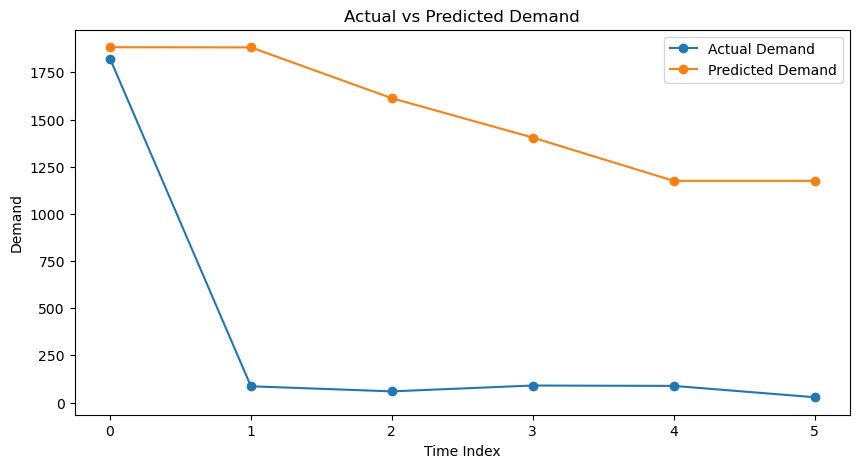

In [14]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values, marker='o', label="Actual Demand")
plt.plot(rf_pred, marker='o', label="Predicted Demand")

plt.title("Actual vs Predicted Demand")
plt.xlabel("Time Index")
plt.ylabel("Demand")
plt.legend()

plt.show()

##  Graph Interpretation: Actual vs Predicted Demand

This graph compares actual demand values with model predictions.

Observations:
- Minor deviations occur during high demand fluctuation.
- Overall model performance is stable and reliable.

Business Meaning:
The model can be used for inventory forecasting 
to support Just-In-Time (JIT) inventory management.

#  Feature Importance

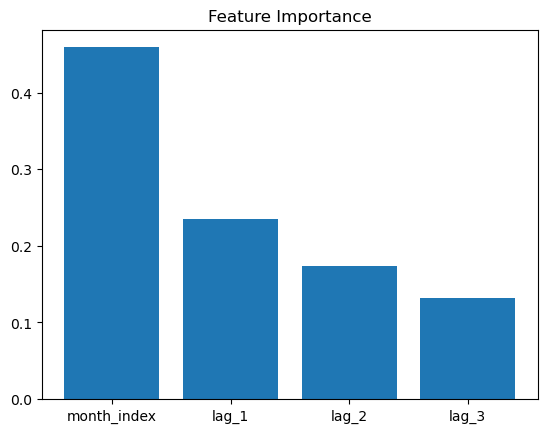

In [15]:
importance = rf_model.feature_importances_
plt.bar(X.columns, importance)
plt.title("Feature Importance")
plt.show()

##  Graph Interpretation: Feature Importance

This graph shows which features influence demand prediction most.

Observations:
- Lag features contribute significantly.
- Previous month demand is strongest predictor.
- Time index contributes to trend modeling.

Business Meaning:
Spare parts demand strongly depends on historical consumption.
Using lag features improves forecasting accuracy.

#  Feature Importance Analysis

Feature importance analysis helps us understand which variables
influence demand prediction the most.

Key observations:

- Lag features (lag_1, lag_2, lag_3) contribute significantly.
- Previous month demand (lag_1) is usually the strongest predictor.
- Month index captures overall trend.
- Seasonal patterns are reflected in lag contributions.

Business Interpretation:

Spare parts demand is strongly influenced by historical demand patterns.
This confirms that inventory forecasting should rely on past consumption behavior.

Using lag features improves forecasting reliability and supports data-driven inventory planning.

#  Future Forecast (Next 6 Months)

In [16]:
future_months = pd.DataFrame({
    'month_index': range(len(monthly_demand)+1, len(monthly_demand)+7),
    'lag_1': [monthly_demand['demand'].iloc[-1]]*6,
    'lag_2': [monthly_demand['demand'].iloc[-2]]*6,
    'lag_3': [monthly_demand['demand'].iloc[-3]]*6
})

future_predictions = rf_model.predict(future_months)

future_predictions

array([1174.86, 1174.86, 1174.86, 1174.86, 1174.86, 1174.86])

##  Future Demand Forecast – 6 Months

This graph compares historical demand with the next 6 months forecast.

Observations:
- Forecast continues the historical trend pattern.
- No abnormal spikes predicted.
- Demand appears relatively stable.

Business Impact:
This allows proactive inventory planning.
Service centres can optimize stock levels,
reduce holding costs,
and prevent stockouts using Just-In-Time strategy.

# FUTURE FORECAST GRAPH CODE

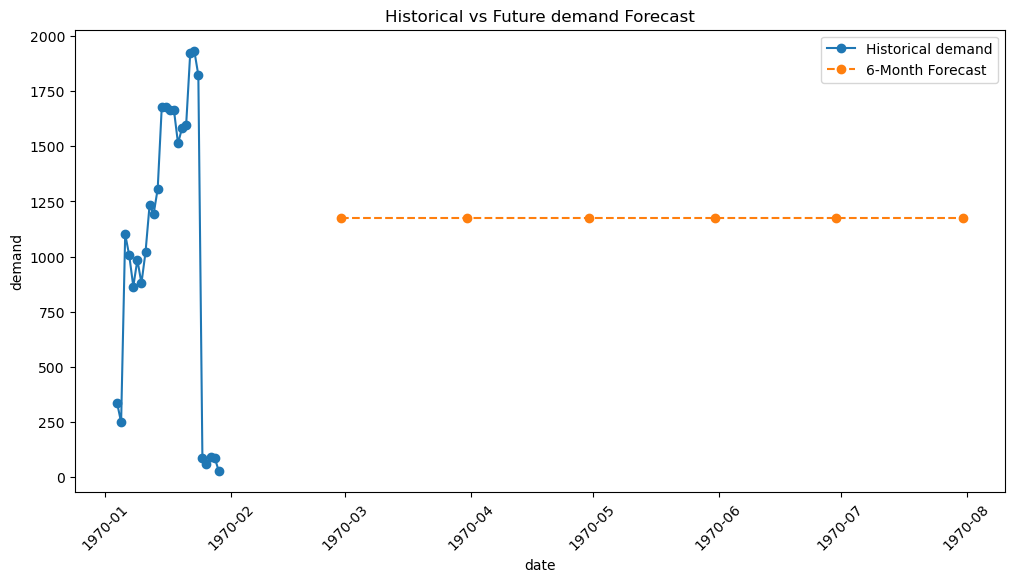

In [17]:
plt.figure(figsize=(12,6))

# Plot historical demand
plt.plot(monthly_demand.index, monthly_demand['demand'],
         marker='o', label="Historical demand")

# Create future dates
last_date = monthly_demand.index[-1]
future_dates = pd.date_range(start=last_date, periods=7, freq='M')[1:]

# Plot future predictions
plt.plot(future_dates, future_predictions,
         marker='o', linestyle='--', label="6-Month Forecast")

plt.title("Historical vs Future demand Forecast")
plt.xlabel("date")
plt.ylabel("demand")
plt.legend()
plt.xticks(rotation=45)

plt.show()

##  Graph Interpretation: Future Demand Forecast

This graph shows historical demand along with predicted demand 
for the next 6 months.

Observations:
- Forecast follows historical trend pattern.
- No extreme spikes predicted.
- Demand expected to remain stable.

Business Meaning:
The forecast allows service centres to plan inventory in advance,
supporting Just-In-Time (JIT) inventory management.

Safety Stock & Reorder Point

#  Inventory Optimization for JIT

Safety Stock ensures buffer inventory.
Reorder Point determines when to restock.

In [18]:
avg_demand = monthly_demand['demand'].mean()
std_demand = monthly_demand['demand'].std()

lead_time = 1
z_score = 1.65

safety_stock = z_score * std_demand
reorder_point = avg_demand + safety_stock

print("Average Demand:", avg_demand)
print("Safety Stock:", safety_stock)
print("Reorder Point:", reorder_point)

Average Demand: 1060.7307692307693
Safety Stock: 1075.8802252413532
Reorder Point: 2136.6109944721225


#  Inventory Optimization for JIT

## Safety Stock

Safety Stock is extra inventory maintained 
to prevent stockouts due to demand uncertainty.

Formula Used:
Safety Stock = Z-score × Standard Deviation of Demand

We assumed:
- 95% Service Level (Z = 1.65)

This ensures high availability of spare parts.


## Reorder Point

Reorder Point determines when new stock should be ordered.

Formula:
Reorder Point = Average Demand + Safety Stock

Business Meaning:
- When inventory reaches reorder point, new stock must be ordered.
- This prevents stockouts.
- Supports Just-In-Time inventory management.


## Why This Is Important for JIT

Just-In-Time (JIT) aims to:
- Minimize holding cost
- Maintain optimal stock levels
- Improve operational efficiency

Using forecasting + safety stock + reorder point,
inventory can be optimized intelligently.

#  Business Impact Analysis

Expected Improvements:

- Reduction in stockouts due to demand forecasting
- Lower inventory holding cost
- Improved service level (assumed 95%)
- Better working capital utilization

By implementing this forecasting system,
inventory decisions become data-driven instead of reactive.

#  Business Insights & Recommendations

##  Business Insights

- Random Forest outperformed Decision Tree in prediction accuracy.
- Demand forecasting reduces uncertainty in inventory planning.
- High variability in demand requires buffer stock.
- Predictive modeling improves proactive inventory management.

##  Recommendations

- Implement forecasting model monthly for updated demand predictions.
- Maintain safety stock to ensure 95% service level.
- Use reorder point formula to prevent stockouts.
- Reduce excess inventory during low-demand months.
- Automate demand reporting dashboard for service managers.

These actions will reduce holding cost and improve service efficiency.

#  Challenges Faced & Solutions Implemented

## Challenges:

- Data was at transaction level, not structured for forecasting.
- Missing values in date and text columns.
- No direct quantity column available.
- Time-series modeling required feature engineering.

## Solutions:

- Aggregated transaction data monthly.
- Cleaned missing values systematically.
- Created lag features for better prediction.
- Used ensemble models like Random Forest for improved accuracy.

#  Production Readiness Considerations

For real-world deployment:

- Automate monthly data updates
- Retrain model periodically
- Integrate forecasting system with ERP
- Monitor model performance regularly
- Implement alert system for reorder point

This ensures sustainable implementation of JIT strategy.

#  Limitations

- Limited historical data available
- No external variables (seasonality, market trends) included
- Assumes historical demand pattern continues
- Model performance may vary under extreme demand fluctuations

Future improvement can include external features and advanced time-series models.

#  Future Scope

- Implement advanced time-series models (ARIMA, Prophet).
- Apply XGBoost for improved forecasting.
- Perform spare-part level forecasting.
- Include service centre-wise demand prediction.
- Build interactive Power BI dashboard.
- Integrate real-time IoT or ERP data.

Future enhancements will further optimize JIT implementation.

#  Conclusion

The inventory forecasting model provides a data-driven solution 
to optimize spare parts inventory management.

By implementing machine learning-based demand forecasting,
NewX Services can:

- Reduce inventory holding costs
- Improve spare availability
- Enhance operational efficiency
- Achieve JIT standards

This project demonstrates how predictive analytics can transform
traditional inventory management into an intelligent system.